In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
bench_data = pd.read_csv("data_extraction/bench_road_enrichment.csv")
plaque_data = pd.read_csv("data_extraction/open-plaques-United-Kingdom-2025-12-14-footway.csv")

In [86]:
monument_file = "data_extraction/monuments.csv"

import pandas as pd

# Read a tab-separated download instead.
monuments_df = pd.read_csv(monument_file, sep="\t", encoding="utf-8-sig")
monuments_df = monuments_df[~monuments_df.memorial.apply(lambda x: "plaque" in x.lower() if isinstance(x, str) else False)]
monuments_df.columns
monuments_df.to_csv("data_extraction/monuments.csv", index=False, sep="\t", encoding="utf-8-sig")
monuments_df.columns

Index(['@type', '@id', 'name', 'subject', 'memorial', 'inscription',
       'wikidata', 'heritage', '@lat', '@lon'],
      dtype='str')

In [23]:
highway_types = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'residential', 'service']

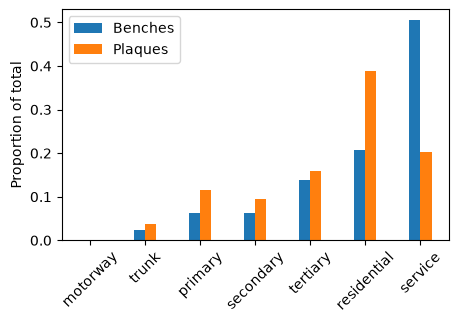

In [ ]:
plaques = plaque_data.highway.value_counts()
benches = bench_data.highway.value_counts()

fig,ax = plt.subplots(figsize=(5,3))
# plot benches and plaques on the same axis, bars side by side
# order the bars by highway type

highway_order = [h for h in highway_types if h in benches.index and h in plaques.index]
benches = benches[highway_order]
plaques = plaques[highway_order]
tot_plaques = plaques.sum()
tot_benches = benches.sum()

pl1 = ax.bar(np.linspace(0, len(benches)-1, len(benches))-0.1, benches.values/tot_benches, width=0.2, label='Benches', align='center')
pl2 = ax.bar(np.linspace(0, len(plaques)-1, len(plaques))+0.1, plaques.values/tot_plaques, width=0.2, label='Plaques', align='center')

ax.set_xticks(np.arange(len(benches)))
ax.set_xticklabels(benches.index, rotation=45)
ax.set_ylabel('Proportion of total')
ax.legend()

In [ ]:
bench_file = "data_extraction/data.json"
bench_data_all = pd.read_json(bench_file)

unfound_ids = bench_data[(bench_data.highway.isna()) & (bench_data.is_in_uk == True)]['feature_id']
bench_ids = bench_data_all.features.apply(lambda x: x['id'])


In [42]:
bench_data_all[bench_ids.isin(unfound_ids)]['features'].apply(lambda x: x["properties"]['popupContent'])

281      Higgins Greenhalgh\r\n1986 - 2000\r\nWe hadn't...
11584    This beech copse planted\r\nby kind donation f...
13968    In Loving Memory Of\r\nJACK & EMMIE WRIGHT\r\n...
15818               1952 2017\r\nJANET DAY LOVED ULLSWATER
17201    In Loving Memory of Elizabeth (Betty) Dix\nJan...
17916           Formakin Children's Wood\nEstablished 2006
17930    In loving memory of \nCapt Nigel Duncan Ratcli...
18670    IN MEMORY OF\nVAL (HOWLETT)\nA TRUE FRIEND AND...
19190    In Loving Memory of\r\nChristina Lewis (Vaugha...
19922    For My Mum & Dear Aunt\r\nAnn More\r\n1st Nove...
21943    IN LOVING MEMORY OF BOBBY DOOLAN DIED 7 SEPTEM...
23368    ANN'S VIEW\r\nIn loving memory of\r\nAnn Pearc...
23369    1949 Alan Hoy 2015\r\nWho loved to sail these ...
23370    KENNETH WHITEHAIR\r\nWaterman & Lighterman of ...
27387    IN MEMORY OF\r\nHARRY HEARN WHITWELL\r\n(DICK)...
27388    Remembering the best Wife, Mum and Nana\r\nJac...
28294    In loving memory of\r\nRobert George Neville\r.